In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import OrdinalEncoder, TargetEncoder, Normalizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [81]:
dataset = pd.read_csv('../data/life_expectancy/Life Expectancy Data.csv')
dataset.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [82]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Life expectancy '}>,
        <Axes: title={'center': 'Adult Mortality'}>,
        <Axes: title={'center': 'infant deaths'}>],
       [<Axes: title={'center': 'Alcohol'}>,
        <Axes: title={'center': 'percentage expenditure'}>,
        <Axes: title={'center': 'Hepatitis B'}>,
        <Axes: title={'center': 'Measles '}>],
       [<Axes: title={'center': ' BMI '}>,
        <Axes: title={'center': 'under-five deaths '}>,
        <Axes: title={'center': 'Polio'}>,
        <Axes: title={'center': 'Total expenditure'}>],
       [<Axes: title={'center': 'Diphtheria '}>,
        <Axes: title={'center': ' HIV/AIDS'}>,
        <Axes: title={'center': 'GDP'}>,
        <Axes: title={'center': 'Population'}>],
       [<Axes: title={'center': ' thinness  1-19 years'}>,
        <Axes: title={'center': ' thinness 5-9 years'}>,
        <Axes: title={'center': 'Income composition of resources'}>,
        <Axes: title={'center

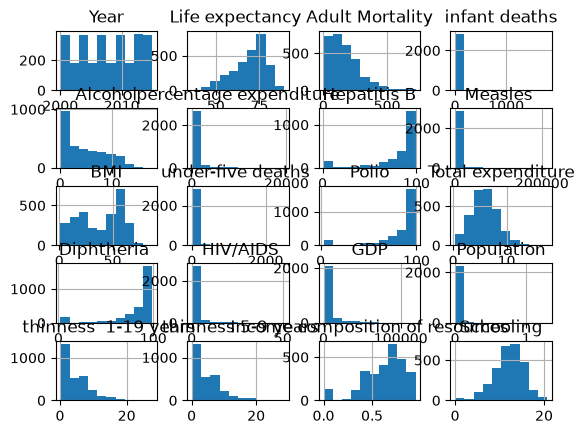

In [83]:
# Exploratory Data Analysis (EDA)

# Distributions via histograms

dataset.hist()

In [84]:
dataset['Status'].value_counts()

Status
Developing    2426
Developed      512
Name: count, dtype: int64

In [85]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

<Axes: xlabel='Status'>

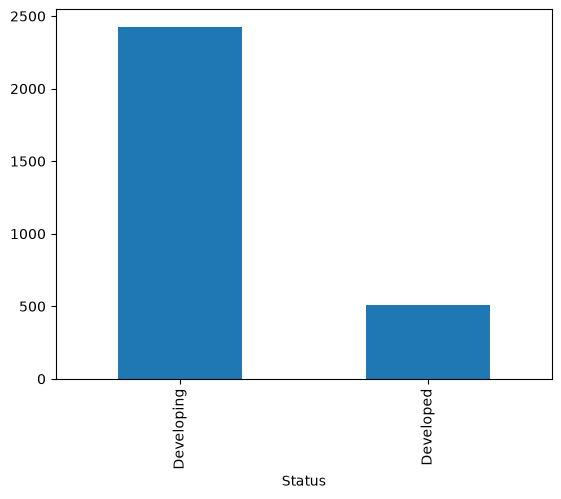

In [86]:
# Encode categorical data with temporary encodings

# dataset_temp = dataset.copy()
# dataset_temp['Country'] = OrdinalEncoder().fit_transform(dataset_temp[['Country']])
# dataset_temp['Status'] = dataset['Status'].replace({'Developing':0, 'Developed':1}).astype('int64')
# print(dataset_temp['Country'].value_counts())
# print(dataset_temp['Status'].value_counts())
# print(dataset['Status'].value_counts())
# print(dataset_temp.info())

# Distributions of categorical data

dataset['Status'].value_counts().plot.bar()

# fig = plt.figure(figsize=(100, 1))
# dataset_temp['Status'].plot.hist()
# sb.countplot(data=dataset, x='Status')
# sb.countplot(data=dataset_temp, x='Status')
# sb.barplot(x=dataset_temp['Country'])
# dataset['Status'].value_counts().plot.bar()


In [87]:
# Correlation
 
correlation = dataset.drop(['Country', 'Status'], axis=1).corr()
correlation.style.background_gradient(cmap='coolwarm')

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
Year,1.000000,0.170033,-0.079052,-0.037415,-0.052990,0.031400,0.104333,-0.082493,0.108974,-0.042937,0.094158,0.090740,0.134337,-0.139741,0.101620,0.016969,-0.047876,-0.050929,0.243468,0.209400
Life expectancy,0.170033,1.000000,-0.696359,-0.196557,0.404877,0.381864,0.256762,-0.157586,0.567694,-0.222529,0.465556,0.218086,0.479495,-0.556556,0.461455,-0.021538,-0.477183,-0.471584,0.724776,0.751975
Adult Mortality,-0.079052,-0.696359,1.000000,0.078756,-0.195848,-0.242860,-0.162476,0.031176,-0.387017,0.094146,-0.274823,-0.115281,-0.275131,0.523821,-0.296049,-0.013647,0.302904,0.308457,-0.457626,-0.454612
infant deaths,-0.037415,-0.196557,0.078756,1.000000,-0.115638,-0.085612,-0.223566,0.501128,-0.227279,0.996629,-0.170689,-0.128616,-0.175171,0.025231,-0.108427,0.556801,0.465711,0.471350,-0.145139,-0.193720
Alcohol,-0.052990,0.404877,-0.195848,-0.115638,1.000000,0.341285,0.087549,-0.051827,0.330408,-0.112370,0.221734,0.296942,0.222020,-0.048845,0.354712,-0.035252,-0.428795,-0.417414,0.450040,0.547378
percentage expenditure,0.031400,0.381864,-0.242860,-0.085612,0.341285,1.000000,0.016274,-0.056596,0.228700,-0.087852,0.147259,0.174420,0.143624,-0.097857,0.899373,-0.025662,-0.251369,-0.252905,0.381952,0.389687
Hepatitis B,0.104333,0.256762,-0.162476,-0.223566,0.087549,0.016274,1.000000,-0.120529,0.150380,-0.233126,0.486171,0.058280,0.611495,-0.112675,0.083903,-0.123321,-0.120429,-0.124960,0.199549,0.231117
Measles,-0.082493,-0.157586,0.031176,0.501128,-0.051827,-0.056596,-0.120529,1.000000,-0.175977,0.507809,-0.136166,-0.106241,-0.141882,0.030899,-0.076466,0.265966,0.224808,0.221072,-0.129568,-0.137225
BMI,0.108974,0.567694,-0.387017,-0.227279,0.330408,0.228700,0.150380,-0.175977,1.000000,-0.237669,0.284569,0.242503,0.283147,-0.243717,0.301557,-0.072301,-0.532025,-0.538911,0.508774,0.546961
under-five deaths,-0.042937,-0.222529,0.094146,0.996629,-0.112370,-0.087852,-0.233126,0.507809,-0.237669,1.000000,-0.188720,-0.130148,-0.195668,0.038062,-0.112081,0.544423,0.467789,0.472263,-0.163305,-0.209373


In [88]:
# Dimensionality compression

In [89]:
# Processing

# Remove missing values

dataset.dropna(inplace=True)

# Imput replacement data

# dataset.fillna(dataset.mean(), inplace=True)

# Encoding

dataset['Status'] = dataset['Status'].replace({'Developing':0, 'Developed':1})


# dataset.dropna(subset='Life expectancy ', inplace=True)
# Data leakage. Should be fitted on training data only
# dataset['Country'] = TargetEncoder().fit_transform(dataset[['Country']], dataset['Life expectancy '])
# dataset.Country.plot.hist()
# Alternativel use one hot encoding

In [90]:
numerical_features = dataset.drop(['Country', 'Status'], axis=1).columns
numerical_features

# Should be done on training data only, and reused for validation and testing
# Mean normalization
# dataset[numerical_features] = (dataset[numerical_features] - dataset[numerical_features].mean())/dataset[numerical_features].std()
# using sklearn
# dataset[numerical_features] = Normalizer().fit_transform(dataset[numerical_features])

Index(['Year', 'Life expectancy ', 'Adult Mortality', 'infant deaths',
       'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ',
       'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ',
       ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years',
       ' thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='str')

In [91]:
# Split our data into TrainValidation and Testing

dataset_trainval, dataset_test = train_test_split(dataset, test_size=0.4, shuffle=True)
features_trainval = dataset_trainval.drop('Life expectancy ', axis=1)
features_test = dataset_test.drop('Life expectancy ', axis=1)
targets_trainval = dataset_trainval['Life expectancy ']
targets_test = dataset_test['Life expectancy ']
print(features_trainval.shape)
print(features_test.shape)



(989, 21)
(660, 21)


In [92]:
country_encoder = TargetEncoder().fit(features_trainval[['Country']], targets_trainval)
features_trainval['Country'] = country_encoder.transform(features_trainval[['Country']])
features_test['Country'] = country_encoder.transform(features_test[['Country']])

In [97]:
def test(model):
    predictions = model.predict(features_test)
    print(f'MSE: {mean_squared_error(targets_test, predictions)}')
    print(f'MAE: {mean_absolute_error(targets_test, predictions)}')
    print(f'R2: {r2_score(targets_test, predictions)}')


In [98]:
# Create and tune a DT

dt_params = {
    'max_depth': [2, 3, 4, 6, 10],
    'max_features': ['sqrt', None, 4]
}

dt_grid = GridSearchCV(DecisionTreeRegressor(), dt_params)
dt_grid.fit(features_trainval, targets_trainval)

test(dt_grid)


MSE: 5.331242947741122
MAE: 1.3551778928983476
R2: 0.931660984041479


In [94]:
cv_results = pd.DataFrame(dt_grid.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007783,0.001920,0.003910,0.000745,2,sqrt,"{'max_depth': 2, 'max_features': 'sqrt'}",0.748520,0.773536,0.814166,0.734720,0.425469,0.699282,0.139546,14
1,0.008310,0.000892,0.003365,0.000761,2,None,"{'max_depth': 2, 'max_features': None}",0.871555,0.861658,0.867774,0.844087,0.865595,0.862134,0.009576,10
2,0.005710,0.000611,0.003033,0.000428,2,4,"{'max_depth': 2, 'max_features': 4}",0.501404,0.721160,0.573289,0.714994,0.581354,0.618440,0.086007,15
3,0.005890,0.000736,0.002976,0.000241,3,sqrt,"{'max_depth': 3, 'max_features': 'sqrt'}",0.816991,0.782795,0.718356,0.713546,0.866118,0.779561,0.058322,13
4,0.009541,0.001326,0.003032,0.000350,3,None,"{'max_depth': 3, 'max_features': None}",0.920562,0.895879,0.926031,0.916474,0.895876,0.910964,0.012686,4
5,0.007498,0.000782,0.004115,0.000122,3,4,"{'max_depth': 3, 'max_features': 4}",0.847116,0.844793,0.885127,0.821011,0.795313,0.838672,0.029862,12
6,0.008445,0.001067,0.004115,0.000510,4,sqrt,"{'max_depth': 4, 'max_features': 'sqrt'}",0.907586,0.910735,0.858926,0.852189,0.845273,0.874942,0.028289,9
7,0.011205,0.001460,0.003033,0.000276,4,None,"{'max_depth': 4, 'max_features': None}",0.934597,0.922842,0.949292,0.929018,0.923055,0.931761,0.009780,3
8,0.005867,0.000734,0.002796,0.000157,4,4,"{'max_depth': 4, 'max_features': 4}",0.807755,0.882125,0.864355,0.862083,0.810747,0.845413,0.030346,11
9,0.006039,0.000275,0.002689,0.000256,6,sqrt,"{'max_depth': 6, 'max_features': 'sqrt'}",0.904387,0.910286,0.922004,0.882143,0.909929,0.905750,0.013125,5


In [104]:
rf_params = {
    'n_estimators': [10, 100, 200, 400], 
    'max_depth': [None, 3, 10]
}
rf_grid = GridSearchCV(RandomForestRegressor(), rf_params, n_jobs=18)
rf_grid.fit(features_trainval, targets_trainval)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 3, ...], 'n_estimators': [10, 100, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",18
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of information pri

In [103]:
test(rf_grid)

MSE: 3.5496867608358955
MAE: 1.0591783103258088
R2: 0.9544980218357337
